ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [ ]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


In [ ]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]

sorted_data = sorted(data_q1)
print("Sorted data:", sorted_data)

import numpy as np
median = np.median(data_q1)
Q1 = np.percentile(data_q1, 25)
Q3 = np.percentile(data_q1, 75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Median:", median)
print("Q1:", Q1, " Q3:", Q3, " IQR:", IQR)
print("Lower fence:", lower_fence, " Upper fence:", upper_fence)

Sorted data: [30, 31, 32, 32, 33, 33, 34, 34, 35, 500]
Median: 33.0
Q1: 32.0  Q3: 34.0  IQR: 2.0
Lower fence: 29.0  Upper fence: 37.0


#### Q1 Answer (Student)

_
First, I sorted the data in ascending order: [30, 31, 32, 32, 33, 33, 34, 34, 35, 500]. Since there are 10 values, the median is the average of the 5th and 6th values, which gives a median of 33. Next, I calculated the first quartile (Q1 = 32) and third quartile (Q3 = 34), and then found the IQR by Q3 - Q1, giving an IQR of 2. Using the IQR rule, the lower fence is 29 and the upper fence is 37. Since the value 500 is greater than 37, it is identified as an outlier. Because this dataset contains a very large outlier, the median and IQR provide a better summary of the data than the mean and standard deviation, as they are less affected by extreme values.
_

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


In [ ]:
def ppv(prevalence, sensitivity, specificity):
    P_D = prevalence
    P_notD = 1 - prevalence
    P_pos_given_D = sensitivity
    P_pos_given_notD = 1 - specificity  # false positive rate

    P_pos = P_pos_given_D * P_D + P_pos_given_notD * P_notD
    P_D_given_pos = (P_pos_given_D * P_D) / P_pos
    return P_D_given_pos, P_pos

ppv_1pct, p_pos_1 = ppv(0.01, 0.90, 0.92)
ppv_20pct, p_pos_20 = ppv(0.20, 0.90, 0.92)

print(f"PPV at 1% prevalence:  {ppv_1pct:.4f}  ({ppv_1pct*100:.2f}%)")
print(f"PPV at 20% prevalence: {ppv_20pct:.4f}  ({ppv_20pct*100:.2f}%)")


PPV at 1% prevalence:  0.1020  (10.20%)
PPV at 20% prevalence: 0.7377  (73.77%)


#### Q2 Answer (Student)

_First, I calculated the probability of getting a positive test result using the law of total probability and found P(+)=0.0882. Then, I applied Bayes' Theorem and found that the PPV is approximately 10.2%. This means that even if a person tests positive, there is only about a 10.2% chance that they actually have the disease because the disease is very rare in the population.

If the disease prevalence increases to 20%, the PPV increases to about 73.8%. This happens because more people in the population actually have the disease, so a positive test result is more likely to be a true positive. Therefore, as prevalence increases, the PPV also increases and the test becomes more reliable._

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

_
1. This is a supervised binary classification problem so we predict premium_user as 0 or 1 using age, region, and daily_clicks as features.

2. (i) Handle missing values
  (ii) One-hot encode
  (iii)Scale numeric features
  (iv)Check and handle class imbalance in premium_user

3. First, we load the dataset and explore it to understand the features, missing values, and overall data patterns. Then, we clean the data by handling missing values, encoding the categorical region column, and scaling numerical features if needed. After preprocessing, we split the dataset into training and testing sets. Next, we train a classification model such as Logistic Regression or Decision Tree using the training data. Finally, we evaluate the model using metrics like accuracy, precision, recall, and F1-score, and improve the model if necessary based on the results.
_

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


Missing values per column:
age             2
region          0
purchases       1
premium_user    0
dtype: int64
Numbr of unique values per columne 
age             5
region          4
purchases       6
premium_user    2
dtype: int64
Correlation matrix:


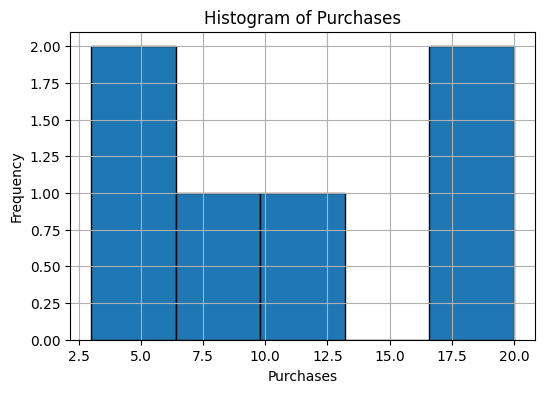

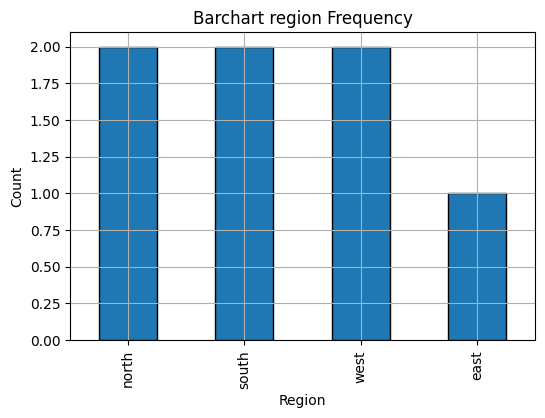

In [ ]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df


# === Number-1 ===

# Missing value summary
print("Missing values per column:")
print(df.isnull().sum())

# numbr of unique values per columne
print("Numbr of unique values per columne ")
print(df.nunique())

# Correlation among numeric columns
numeric_df = df.select_dtypes(include=[np.number])
print("Correlation matrix:")
numeric_df.corr()

# Histogram
plt.figure()
df['purchases'].dropna().plot(kind='hist', bins=5, edgecolor='black')
plt.title("Histogram of Purchases")
plt.xlabel("Purchases")
plt.ylabel("Frequency")
plt.show()

# Barchart
plt.figure()
df['region'].value_counts().plot(kind='bar', edgecolor='black')
plt.title("Barchart region Frequency")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()


In [ ]:
# === Number-2 ===

# Impute age with median
age_imputer = SimpleImputer(strategy='median')
df['age'] = age_imputer.fit_transform(df[['age']])

# Impute purchases with mean.
purchases_imputer = SimpleImputer(strategy='mean')
df['purchases'] = purchases_imputer.fit_transform(df[['purchases']])

df

,age,region,purchases,premium_user
0,25.0,north,3.000000,0
1,30.0,south,10.000000,1
2,30.0,north,5.000000,0
3,22.0,east,10.833333,0
4,45.0,west,20.000000,1
5,52.0,west,18.000000,1
6,30.0,south,9.000000,0


In [ ]:
# === Number-2 ===
# One-hot encode region
df_encoded = pd.get_dummies(df, columns=['region'], prefix='region')
df_encoded

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,25.0,3.000000,0,False,True,False,False
1,30.0,10.000000,1,False,False,True,False
2,30.0,5.000000,0,False,True,False,False
3,22.0,10.833333,0,True,False,False,False
4,45.0,20.000000,1,False,False,False,True
5,52.0,18.000000,1,False,False,False,True
6,30.0,9.000000,0,False,False,True,False


In [ ]:
# === Number-2 ===
# Scale all numeric columns using RobustScaler
numeric_cols = ['age', 'purchases']
scaler = RobustScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])
df_encoded

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,-0.943820,0,False,True,False,False
1,0.0,0.000000,1,False,False,True,False
2,0.0,-0.674157,0,False,True,False,False
3,-0.8,0.112360,0,True,False,False,False
4,1.5,1.348315,1,False,False,False,True
5,2.2,1.078652,1,False,False,False,True
6,0.0,-0.134831,0,False,False,True,False


In [ ]:
# === Number-2 ===
# Create a domain-driven feature
df_encoded['high_spender'] = (df['purchases'] > df['purchases'].median()).astype(int)
df_encoded


# high_spender flags customers whose purchase count is above the median purchases — a simple, interpretable domain feature that could help a model
# separate high-value customers, which often correlates with being a premium user.

,age,purchases,premium_user,region_east,region_north,region_south,region_west,high_spender
0,-0.5,-0.943820,0,False,True,False,False,0
1,0.0,0.000000,1,False,False,True,False,0
2,0.0,-0.674157,0,False,True,False,False,0
3,-0.8,0.112360,0,True,False,False,False,1
4,1.5,1.348315,1,False,False,False,True,1
5,2.2,1.078652,1,False,False,False,True,1
6,0.0,-0.134831,0,False,False,True,False,0


In [ ]:
# === Number-2 ===
# Final dataframe ready for model training
final_df = df_encoded.copy()
final_df


,age,purchases,premium_user,region_east,region_north,region_south,region_west,high_spender
0,-0.5,-0.943820,0,False,True,False,False,0
1,0.0,0.000000,1,False,False,True,False,0
2,0.0,-0.674157,0,False,True,False,False,0
3,-0.8,0.112360,0,True,False,False,False,1
4,1.5,1.348315,1,False,False,False,True,1
5,2.2,1.078652,1,False,False,False,True,1
6,0.0,-0.134831,0,False,False,True,False,0


_Use additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [ ]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2




,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


In [ ]:
#Split the data into train and test with 80 percent train and 20 percent test.
X = df2[['area_sqft', 'bedrooms']]
y = df2['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (4, 2)  Test shape: (2, 2)


In [ ]:
# Fit a LinearRegression model to predict price from area_sqft and bedrooms.

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Print model intercept, coefficients, and predictions on the test set.
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Intercept: -33.84615384615387
Coefficients: [0.15384615 5.38461538]
Predictions: [100.         130.76923077]


In [ ]:
# Compute the following metrics on the test set. (6 marks)
# Mean Absolute Error (MAE)
# Root Mean Squared Error (RMSE)
# R squared (R²)

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE:  {mae:}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:}")

r2 = r2_score(y_test, y_pred)
print(f"R^2:   {r2:}")


MAE:  19.615384615384613
RMSE: 19.61915499208746
R^2:   -0.7107166337935567


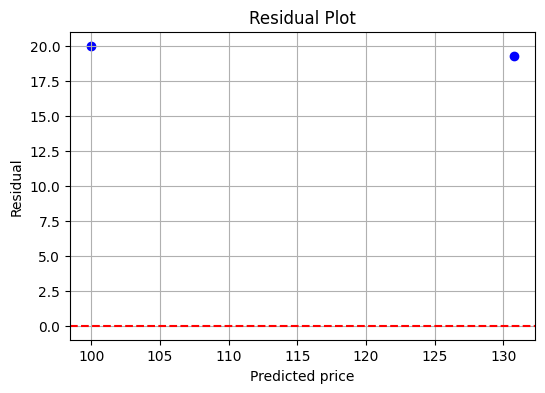

In [ ]:
# Plot a residual plot with y_true − y_pred on the vertical axis and y_pred on the horizontal axi

residuals = y_test.values - y_pred

plt.figure()
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

Explain: If the residuals are randomly spread around zero, it means the linear regression model is working well. If the residuals show a pattern, curve, or funnel shape, it suggests that the data may not follow a linear relationship and the model may not be a good fit.

_Use additional code cells below for train test split, model training, metrics, and the residual plot. Add a brief comment on the residuals in markdown._

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [ ]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Write your code for threshold 0.5 and 0.3 below

In [ ]:
# Threshold 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

cm_05 = confusion_matrix(y_true, y_pred_05)
prec_05 = precision_score(y_true, y_pred_05)
rec_05 = recall_score(y_true, y_pred_05)
f1_05 = f1_score(y_true, y_pred_05)

print("Threshold = 0.5")
print("Predictions:", y_pred_05)
print("Confusion Matrix:\n", cm_05)
print(f"Precision: {prec_05:.3f}")
print(f"Recall:    {rec_05:.3f}")
print(f"F1 score:  {f1_05:.3f}")

Threshold = 0.5
Predictions: [1 0 1 0 1 0 1 0 1 0]
Confusion Matrix:
 [[5 0]
 [0 5]]
Precision: 1.000
Recall:    1.000
F1 score:  1.000


In [ ]:
y_pred_03 = (y_prob >= 0.3).astype(int)

cm_03 = confusion_matrix(y_true, y_pred_03)
prec_03 = precision_score(y_true, y_pred_03)
rec_03 = recall_score(y_true, y_pred_03)
f1_03 = f1_score(y_true, y_pred_03)

print("Threshold = 0.3")
print("Predictions:", y_pred_03)
print("Confusion Matrix:\n", cm_03)
print(f"Precision: {prec_03:.3f}")
print(f"Recall:    {rec_03:.3f}")
print(f"F1 score:  {f1_03:.3f}")

Threshold = 0.3
Predictions: [1 0 1 0 1 1 1 1 1 0]
Confusion Matrix:
 [[3 2]
 [0 5]]
Precision: 0.714
Recall:    1.000
F1 score:  0.833


explan : When the threshold is lowered from 0.5 to 0.3, the model predicts more samples as positive. This usually increases recall because fewer positive cases are missed. However, precision may decrease because more negative cases can be incorrectly classified as positive. Therefore, there is a trade-off between precision and recall when changing the threshold.

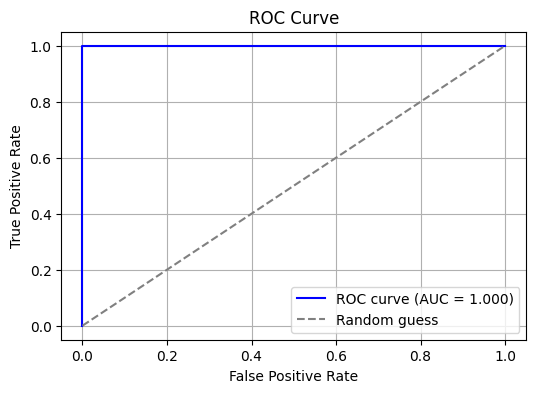

AUC = 1.000


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"AUC = {roc_auc:.3f}")

An AUC value close to 1 means the model can separate positive and negative classes very well. On the other hand, an AUC value close to 0.5 means the model performs like random guessing and cannot distinguish between the classes effectively.

In [ ]:
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

X3 = df3[['hours']]
y3 = df3['passed']

tree_model = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_model.fit(X3, y3)

DecisionTreeClassifier(max_depth=2, random_state=42)

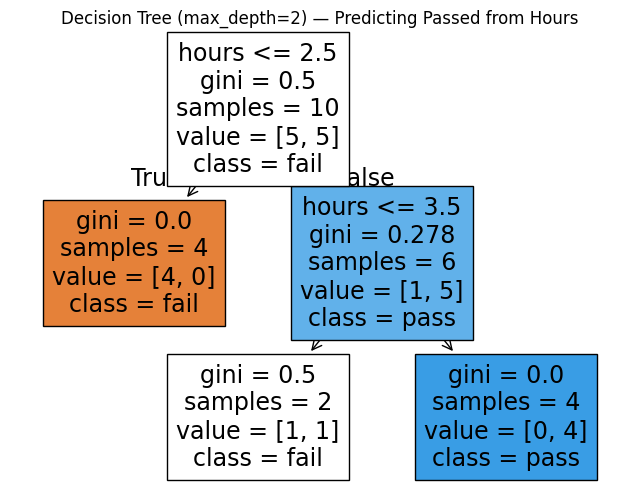

In [ ]:
plt.figure(figsize=(8,6))
plot_tree(tree_model, feature_names=['hours'], class_names=['fail','pass'], filled=True)
plt.title("Decision Tree (max_depth=2) — Predicting Passed from Hours")
plt.show()


From this we see that students studying 3 hours or less thn it  usually fail, while those studying 4 hours or more usually pass. the tree is basically less likely to overfit.